### Start by loading in data

- UN text data
- GDP data
- climate associated words data

In [282]:
import os

"""
GETTING THE TEXT DATA FROM FOLDER DATA/TXT
"""



def get_text_data(output=False, N=False):
    """
    gets all the text data from the subfolders, can print it and you can limit the number of prints
    returns a dictionary with key the title of the file and value the text of the file
    """
    subfolders = []
    for folder in os.listdir('data/TXT'):
        if os.path.isdir(os.path.join('data/TXT', folder)):
            subfolders.append(folder)

    text_data = {}
    for folder in subfolders:
        for file in os.listdir(os.path.join('data/TXT', folder)):
            if file.endswith('.txt'):
                with open(os.path.join('data/TXT', folder, file), 'r') as f:
                    text_data[file] = f.read()
                    if output:
                        print(f"Title: {file}")
                        print(f"Text: {text_data[file]}")
                        print("\n")
                    if N and len(text_data) >= N:
                        return text_data
    return text_data

#test with first file
text_data = get_text_data()
print(text_data["ARG_01_1946.txt"])


KeyboardInterrupt: 

In [333]:
import keyword
import regex as re

climate_words_dict = {"greenhouse_gases_and_emissions": [
        "carbon dioxide", "co2", "methane", "ch4", "nitrous oxide", "n2o",
        "fluorinated gases", "greenhouse effect", "carbon emissions",
        "scope 1 emissions", "scope 2 emissions", "scope 3 emissions",
        "carbon footprint", "carbon budget", "emission intensity", "flaring"
    ],
    "climate_science_and_phenomena": [
        "global warming", "surface temperature", "temperature anomaly",
        "radiative forcing", "albedo effect", "feedback loop", "tipping point",
        "keeling curve", "ocean acidification", "paleoclimatology", "antarctic ice sheet",
        "arctic sea ice", "permafrost thawing", "glacier retreat", "thermohaline circulation",
        "el nino", "la nina", "enso", "polar vortex", "climate change"
    ],
    "extreme_weather_and_impacts": [
        "sea level rise", "storm surge", "coastal erosion", "flash drought",
        "megadrought", "heatwave", "heat dome", "wildfire", "forest fire",
        "tropical cyclone", "typhoon", "hurricane intensification",
        "biodiversity loss", "coral bleaching", "species extinction",
        "habitat fragmentation", "vector-borne disease", "water scarcity"
    ],
    "energy_and_technology": [
        "clean energy", "renewable energy", "solar photovoltaic", "wind turbine",
        "geothermal", "hydroelectric", "nuclear energy", "grid storage",
        "battery storage", "green hydrogen", "electrification", "heat pump",
        "electric vehicles", "ev adoption", "carbon capture and storage", "ccs",
        "direct air capture", "dac", "bioenergy"
    ],
    "policy_agreements_and_economics": [
        "ipcc", "cop28", "cop29", "cop30", "paris agreement", "unfccc",
        "nationally determined contributions", "ndc", "carbon pricing",
        "carbon tax", "cap and trade", "emissions trading system", "ets",
        "esg", "green finance", "loss and damage", "carbon border adjustment mechanism",
        "cbam", "net zero", "carbon neutrality", "climate justice"
    ],
    "adaptation_and_nature_solutions": [
        "climate adaptation", "climate resilience", "afforestation",
        "reforestation", "blue carbon", "mangrove restoration",
        "regenerative agriculture", "soil carbon sequestration",
        "rewilding", "sponge cities", "flood defense", "sea wall"
    ]
}

In [ ]:
import numpy as np
import pandas as pd

# 1. Load data
gdp = pd.read_csv("data/GDP.csv")

# 2. Melt wide columns into long format
year_cols = [c for c in gdp.columns if c.isdigit()]
gdp_long = gdp.melt(
    id_vars=["Country Code"],
    value_vars=year_cols,
    var_name="year",
    value_name="gdp",
)

# 3. Clean types and column names
gdp_long["year"] = gdp_long["year"].astype(int)
gdp_long["country"] = gdp_long["Country Code"].str.strip().str.upper()
gdp_long["gdp"] = pd.to_numeric(gdp_long["gdp"], errors="coerce")

# 4. Filter positive values & compute logarithm
gdp_long = gdp_long[gdp_long["gdp"] > 0].copy()
gdp_long["log_gdp"] = np.log(gdp_long["gdp"])

# 5. Extract clean panel dataframe
df_gdp_clean = gdp_long[["country", "year", "gdp", "log_gdp"]].reset_index(drop=True)

# 6. (Optional) Lookup series for O(1) access
gdp_lookup = df_gdp_clean.set_index(["country", "year"])["log_gdp"]

In [ ]:
# load the share of renewable energy data
renewable_energy = pd.read_csv("data/API_EG.FEC.RNEW.ZS_DS2_en_csv_v2_372598.csv")
renewable_energy.drop(columns=["Indicator Name", "Indicator Code", "Unnamed: 70"], inplace=True)

In [ ]:
renewable_energy

,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.000000,6.800000,8.600000,8.300000,9.10000,8.8,8.8,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,61.822884,61.426950,61.587530,62.690710,65.78238,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,20.200000,19.500000,18.300000,18.900000,18.20000,20.0,20.0,NaN,NaN,NaN
3,Africa Western and Central,AFW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,75.796840,76.101681,75.476578,75.078788,75.84698,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.100000,52.500000,52.500000,51.000000,60.10000,52.9,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,Kosovo,XKX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
261,"Yemen, Rep.",YEM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.600000,3.000000,2.900000,3.000000,3.50000,3.7,NaN,NaN,NaN,NaN
262,South Africa,ZAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.800000,7.900000,8.000000,8.700000,9.80000,9.7,NaN,NaN,NaN,NaN
263,Zambia,ZMB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,84.000000,83.500000,83.800000,86.100000,85.40000,83.0,NaN,NaN,NaN,NaN


## clean the text data and first scan

### speech data
---
We will use nltk module "stopwords" to remove stop words from the text data. 
The analysis will mainly focus on finding certain words in the text. By removing stop words, we do not have to match those words against words we are looking for. This will speed up the analysis. 
Furthermore, when doing a broader sentiment analysis, stop words will not be usefull and only make the text less information dense.

When we use the ClimateBERT model later, we use a versino of the text that does include stopwords. This is because the model is trained on real text, so we should not alter it. 

After removing stop words, we will quicky count the number of words per speech per country. This gives an indication of how long the speeches are and if they differ in lenght. This information is not needed for the final analysis, but helps with understanding the data.

In [ ]:
import nltk
nltk.download('stopwords')

def speech_set(text_data):
    """
    replaces dict value with set instead of list
    """
    for key in text_data:
        text_data[key] = set(text_data[key].split())
    return text_data

def speech_set_no_stopwords(text_data):
    """
    removes stopwords (input should be set so call speech_set first)
    """
    stopwords = set(nltk.corpus.stopwords.words('english'))
    
    for key in text_data:
        text_data[key] = text_data[key] - stopwords
    return text_data



text = speech_set(text_data)
text = speech_set_no_stopwords(text)

[nltk_data] Downloading package stopwords to /Users/jacob/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
word_count = {}
for key in text:
    token = key[:3]
    if token not in word_count:
        word_count[token] = []
    word_count[token].append(len(text[key]))

for key in word_count:
    word_count[key] = sum(word_count[key])/len(word_count[key])

sorted_word_count = sorted(word_count.items(), key=lambda x:x[1], reverse=True)

### counting the number of mentions of climate associated words
Combining the data from the UN speeches and the climate associated words, we can count the number of mentions of climate associated words per speech per country per year. We will store it by country, topic and year. 

In [ ]:
import re
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# =====================================================================
# 1. OPTIMIZED PYTORCH DATASET WITH TOKENIZATION WITH GEMINI
# =====================================================================


class SentenceDataset(Dataset):

    def __init__(self, texts):
        self.texts = texts

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx]


def run_unfiltered_climatebert(text_dict, batch_size=128, max_len=128, use_fp16=True):

    # check for apple hardware
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Hardware Acceleration: Apple Silicon M3 GPU (MPS) active.")
    elif torch.cuda.is_available():
        device = torch.device("cuda:0")
        print("Hardware Acceleration: CUDA GPU active.")
    else:
        device = torch.device("cpu")
        print("Hardware Acceleration: Falling back to CPU.")

    # extract every single sentence
    print("Extracting full sentence corpus from speech texts...")
    records = []
    for file_key, speech_content in text_dict.items():
        if file_key.startswith(".") or "DS_Store" in file_key:
            continue

        year = int(file_key[-8:-4])
        country = file_key[:3]

        sentences = [
            s.strip()
            for s in speech_content.split(". ")
            if len(s.strip()) >= 30
        ]

        for s in sentences:
            records.append({"country": country, "year": year, "sentence": s})

    df = pd.DataFrame(records)
    total_sentences = len(df)
    print(f"Total raw sentences queued for inference: {total_sentences:,}")

    # 3. Load Model and Tokenizer
    model_name = "climatebert/distilroberta-base-climate-detector"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)

    # Cast to Half Precision if requested (M3 GPU natively supports FP16)
    if use_fp16 and device.type == "mps":
        model = model.half()

    model.to(device)
    model.eval()

    # Map label IDs (find which index corresponds to 'yes')
    id2label = {int(k): v.lower() for k, v in model.config.id2label.items()}
    yes_idx = [k for k, v in id2label.items() if v == "yes"][0]

    # 4. Collate Function with Dynamic Padding
    # Only pads each batch to the longest sentence IN THAT BATCH (massive speedup)
    def collate_fn(batch):
        return tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors="pt",
        )

    dataset = SentenceDataset(df["sentence"].tolist())
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,  # MPS works best with 0 worker threads on unified memory
        collate_fn=collate_fn,
    )

    # 5. Batched Inference Loop
    predictions = []
    print(f"Running batch inference (batch_size={batch_size})...")

    with torch.inference_mode():  # Faster and less memory than torch.no_grad()
        for batch in tqdm(loader, desc="ClimateBERT Evaluation"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            # Argmax to determine predicted class
            batch_preds = torch.argmax(logits, dim=-1).cpu().numpy()
            is_climate_binary = (batch_preds == yes_idx).astype(int)
            predictions.extend(is_climate_binary)

    df["is_climate"] = predictions

    # 6. Aggregate to Country-Year Panel
    print("Aggregating country-year panel statistics...")
    df_country_year = (
        df.groupby(["country", "year"])
        .agg(
            total_sentences=("sentence", "count"),
            climate_sentences=("is_climate", "sum"),
        )
        .reset_index()
    )

    df_country_year["climate_sentence_ratio"] = (
        df_country_year["climate_sentences"]
        / df_country_year["total_sentences"]
    )

    return df_country_year.sort_values(["country", "year"]).reset_index(
        drop=True
    )

In [ ]:
from locale import normalize
from turtle import rt
import pandas as pd
import re

def extract_climate_keywords(text, climate_words_dict):
    """
    Creates a DataFrame that counts per country per year the number of mentions of keywords in from the manual dictionary
    """
    records = []

    for country_speech_year, speech_tokens in text.items():

        if "DS_Store" in country_speech_year:
            continue  
        
        country = country_speech_year[:3]
        year = int(country_speech_year[-8:-4])
    
        speech_str = " ".join(speech_tokens)
        
        for topic, word_list in climate_words_dict.items():
            pattern = re.compile(r"\b(" + "|".join(re.escape(w) for w in word_list) + r")\b", re.IGNORECASE)
            matches = pattern.findall(speech_str)
            
            if matches:
                records.append({
                    "country": country,
                    "year": year,
                    "topic": topic,
                    "mention_count": len(matches),
                    "matched_words": list(set(m.lower() for m in matches)),
                    "total_words": len(speech_tokens),
                    "normalised_mention_count": len(matches) / len(speech_tokens) if len(speech_tokens) > 0 else 0
                })

    df_keywords = pd.DataFrame(records)
    df_keywords_topic = df_keywords.groupby(['country', 'year', "topic"]).sum('mention_count')
    df_keywords_topic


    df_pivot = df_keywords_topic.pivot_table(
        index=['country', "year"],
        columns='topic',
        values='mention_count',
        aggfunc='sum',
        fill_value=0
    )
    return df_pivot

In [332]:

# first check if file exists, if not run the function so we do not have to wait hours :)
try:
    # open csv version
    df_climate_panel = pd.read_csv("data/df_climate_panel.csv")
except:
    df_climate_panel = run_unfiltered_climatebert(text_dict=text_data, batch_size=128, max_len=128, use_fp16=True)
    df_keywords = extract_climate_keywords(text=text, climate_words_dict=climate_words_dict)
    df_climate_panel.rename(columns={"climate_sentences": "climate_sentences_BERT", "climate_sentence_ratio": "climate_sentence_ratio_BERT"}, inplace=True)
    df_climate_panel = pd.merge(df_keywords.reset_index(), df_climate_panel, on=["country", "year"], how="outer").fillna(0)
    df_climate_panel.to_csv("data/df_climate_panel.csv", index=False)

display(df_climate_panel)

,country,year,adaptation_and_nature_solutions,climate_science_and_phenomena,energy_and_technology,extreme_weather_and_impacts,greenhouse_gases_and_emissions,policy_agreements_and_economics,total_sentences,climate_sentences_BERT,climate_sentence_ratio_BERT
0,AFG,1952,0.0,0.0,0.0,0.0,0.0,0.0,19,0,0.000000
1,AFG,1957,0.0,0.0,0.0,0.0,0.0,0.0,24,0,0.000000
2,AFG,1958,0.0,0.0,0.0,0.0,0.0,0.0,51,0,0.000000
3,AFG,1959,0.0,0.0,0.0,0.0,0.0,0.0,95,0,0.000000
4,AFG,1960,0.0,0.0,0.0,0.0,0.0,0.0,54,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
11136,ZWE,2021,0.0,0.0,0.0,0.0,0.0,0.0,40,13,0.325000
11137,ZWE,2022,0.0,0.0,0.0,0.0,0.0,0.0,73,17,0.232877
11138,ZWE,2023,0.0,0.0,0.0,0.0,0.0,0.0,55,17,0.309091
11139,ZWE,2024,0.0,0.0,0.0,0.0,0.0,0.0,70,16,0.228571


In [330]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm


def melt_renewable_energy(df_renew_wide):
    """
    Reshapes renewable energy DataFrame into country-year panel.
    """
    year_cols = [c for c in df_renew_wide.columns if str(c).isdigit()]

    df_long = df_renew_wide.melt(id_vars=["Country Code", "Country Name"], value_vars=year_cols, var_name="year", value_name="renew_pct")

    df_long["year"] = df_long["year"].astype(int)
    df_long["country"] = df_long["Country Code"].str.strip().str.upper()
    df_long["renew_pct"] = pd.to_numeric(df_long["renew_pct"], errors="coerce")

    return df_long.dropna(subset=["renew_pct"])[["country", "year", "renew_pct"]]


def prepare_climate_renew_data(df_climate_panel, df_renew_wide, lag_years=1, start_year=2000, end_year=2022,):
    """
    Merges ClimateBERT speech metrics with lagged renewable energy adoption at the country-year panel level.
    """
    df_renew = melt_renewable_energy(df_renew_wide)
    df_renew["year_for_merge"] = df_renew["year"] + lag_years

    # Merge on country and year
    df_merged = pd.merge(df_climate_panel, df_renew, left_on=["country", "year"], right_on=["country", "year_for_merge"], how="inner", suffixes=("", "_renew"))
    df_merged = df_merged[(df_merged["year"] >= start_year) & (df_merged["year"] <= end_year) ].copy()
    
    return df_merged

def run_climate_renew_regression(df_model, speech_col="climate_sentence_ratio", target_col="renew_pct", lag_years=10, plot_=True, mean=False):
    """
    Predicts renewable energy % from climate speech rhetoric and log_gdp.
    Automatically applies clustered standard errors for panel data, and HC1 for cross-sectional means.
    """
    formula = f"{target_col} ~ {speech_col} + log_gdp"
    model = smf.ols(formula=formula, data=df_model).fit(cov_type="cluster", cov_kwds={"groups": df_model["country"]})


    print(f"=================== REGRESSION: {['mean ' if mean else ''][0]}{target_col} ~ {speech_col} + log_gdp (Lag={lag_years}yr) ===================")
    print(model.summary())

    if plot_:
        fig = plt.figure(figsize=(12, 5))
        sm.graphics.plot_partregress_grid(model, fig=fig)
        title_suffix = "Panel (Clustered)" if not mean else "Country Means (Cross-Section)"
        plt.suptitle(f"Partial Regression Plots: Predicting {target_col} [{title_suffix}]", fontsize=13, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.show()

    return model

=================== REGRESSION: renew_pct ~ climate_sentence_ratio_BERT + log_gdp (Lag=10yr) ===================
                            OLS Regression Results                            
Dep. Variable:              renew_pct   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     17.85
Date:                Wed, 23 Sep 2026   Prob (F-statistic):           7.92e-08
Time:                        10:53:28   Log-Likelihood:                -20210.
No. Observations:                4193   AIC:                         4.043e+04
Df Residuals:                    4190   BIC:                         4.045e+04
Df Model:                           2                                         
Covariance Type:              cluster                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-

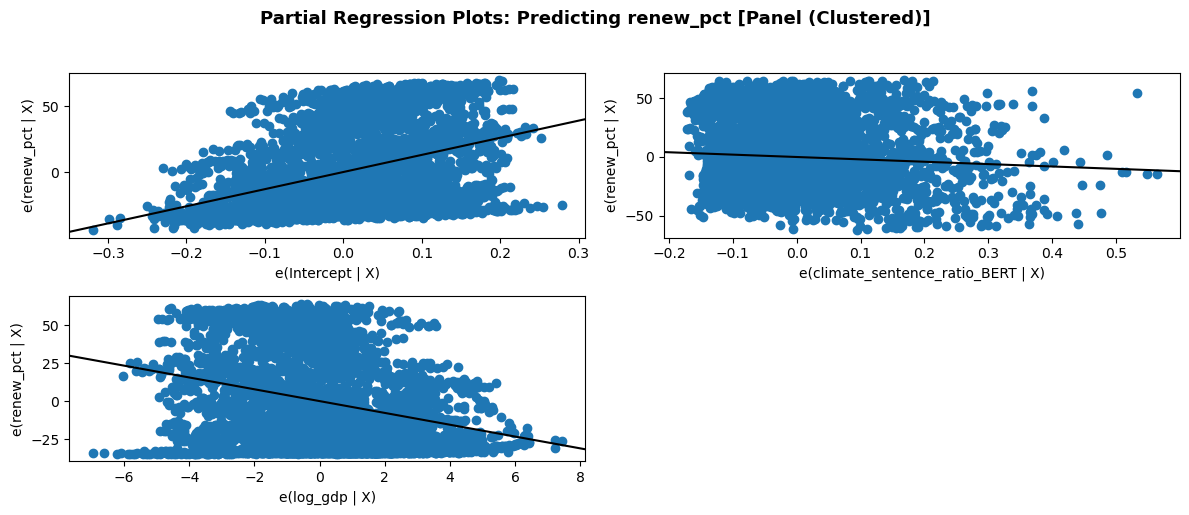

=================== REGRESSION: mean renew_pct ~ climate_sentence_ratio_BERT + log_gdp (Lag=10yr) ===================
                            OLS Regression Results                            
Dep. Variable:              renew_pct   R-squared:                       0.101
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     15.83
Date:                Wed, 23 Sep 2026   Prob (F-statistic):           4.40e-07
Time:                        10:53:33   Log-Likelihood:                -911.59
No. Observations:                 190   AIC:                             1829.
Df Residuals:                     187   BIC:                             1839.
Df Model:                           2                                         
Covariance Type:              cluster                                         
                                  coef    std err          z      P>|z|      [0.025      0.9

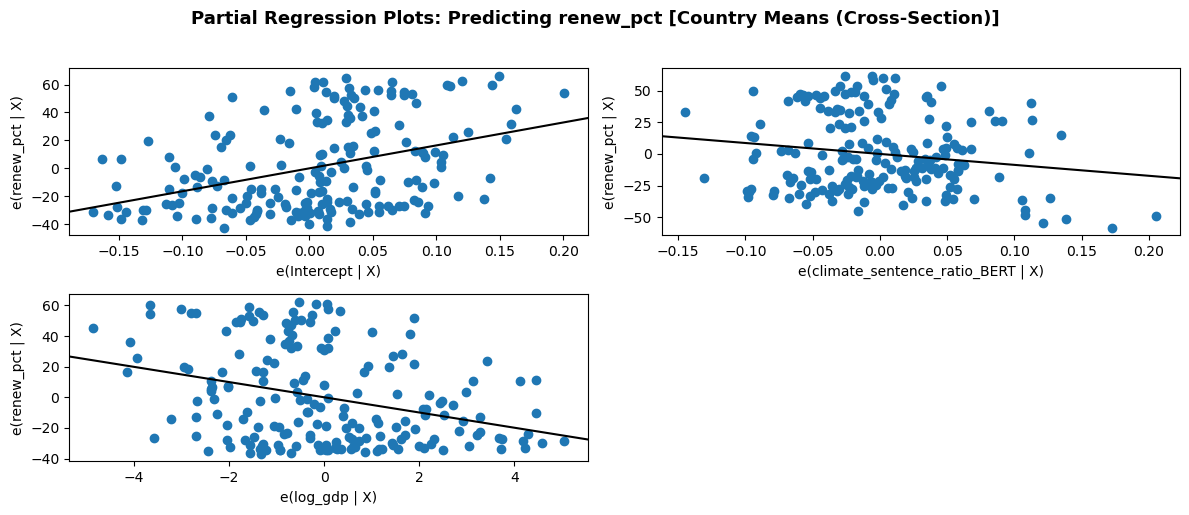

In [331]:
df_panel = prepare_climate_renew_data(df_climate_panel=df_climate_panel, df_renew_wide=renewable_energy, lag_years=10, start_year=1970, end_year=2022)
df_model = pd.merge(df_panel, df_gdp_clean[["country", "year", "log_gdp"]], on=["country", "year"], how="inner").dropna(subset=["renew_pct", "log_gdp", "climate_sentence_ratio_BERT"])
df_model_mean = df_model.groupby("country")[["climate_sentence_ratio_BERT", "renew_pct", "log_gdp"]].mean().reset_index()
model_panel = run_climate_renew_regression(df_model=df_model, speech_col="climate_sentence_ratio_BERT", target_col="renew_pct", lag_years=10, plot_=True)
model_mean = run_climate_renew_regression(df_model=df_model_mean, speech_col="climate_sentence_ratio_BERT", target_col="renew_pct", lag_years=10, plot_=True, mean=True)

In [334]:
df_model

,country,year,adaptation_and_nature_solutions,climate_science_and_phenomena,energy_and_technology,extreme_weather_and_impacts,greenhouse_gases_and_emissions,policy_agreements_and_economics,total_sentences,climate_sentences_BERT,climate_sentence_ratio_BERT,year_renew,renew_pct,year_for_merge,log_gdp
0,AFG,2002,0.0,0.0,0.0,0.0,0.0,0.0,41,1,0.024390,1992,27.4,2002,22.072438
1,AFG,2003,0.0,0.0,0.0,0.0,0.0,0.0,59,0,0.000000,1993,28.5,2003,22.236082
2,AFG,2004,0.0,0.0,0.0,0.0,0.0,0.0,46,0,0.000000,1994,30.1,2004,22.375921
3,AFG,2005,0.0,0.0,0.0,0.0,0.0,0.0,32,0,0.000000,1995,31.8,2005,22.552032
4,AFG,2006,0.0,0.0,0.0,0.0,0.0,0.0,56,0,0.000000,1996,33.9,2006,22.665080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4188,ZWE,2018,0.0,0.0,0.0,0.0,0.0,0.0,52,9,0.173077,2008,81.6,2018,24.254206
4189,ZWE,2019,0.0,0.0,0.0,0.0,0.0,0.0,42,7,0.166667,2009,82.6,2019,23.806653
4190,ZWE,2020,0.0,0.0,0.0,0.0,0.0,0.0,32,3,0.093750,2010,81.2,2020,23.791770
4191,ZWE,2021,0.0,0.0,0.0,0.0,0.0,0.0,40,13,0.325000,2011,77.2,2021,24.068642


## TODO

- plot averages and single countries per year and see how they change
- cluster countries by gdp, or % renew and look for patterns
- risk level and gdp are interesting mediators in relation of mentions to renawables

In [ ]:
# now we will count how often each country names other countries using country_list as check
records = []
for country_speech_year, speech_tokens in text.items():
    if "DS_Store" in country_speech_year:
        continue  
    
    country = country_speech_year[:3]
    year = int(country_speech_year[-8:-4])
    
    speech_str = " ".join(speech_tokens)
    
    for other_country in list_of_countries:
        if other_country.lower() in speech_str.lower():
            records.append({
                "country": country,
                "year": year,
                "mentioned_country": other_country
            })  

df_mentions = pd.DataFrame(records)

In [ ]:
# rework the df such that it lists how often a country is mentioned by another one (instead of who's mentioning whom)
# df_mentions_count = df_mentions.groupby(['mentioned_country', 'country'])
df_mentions[df_mentions["year"]==2020]

,country,year,mentioned_country
32992,ISL,2020,Belarus
32993,ISL,2020,Georgia
32994,ISL,2020,Iceland
32995,ISL,2020,Libya
32996,ISL,2020,Ukraine
...,...,...,...
33916,AND,2020,World
33917,BHR,2020,Bahrain
33918,BHR,2020,Israel
33919,BHR,2020,Libya


topic         adaptation_and_nature_solutions  climate_science_and_phenomena  \
country year                                                                   
AFG     1983                                0                              0   
        1984                                0                              0   
        2008                                0                              0   
AGO     2022                                0                              0   
        2024                                0                              0   
...                                       ...                            ...   
ZAF     2015                                0                              0   
ZMB     2016                                0                              0   
        2024                                0                              0   
        2025                                0                              0   
ZWE     2025                                0                              0   

topic         energy_and_technology  extreme_weather_and_impacts  \
country year                                                       
AFG     1983                      1                            0   
        1984                      1                            0   
        2008                      0                            1   
AGO     2022                      1                            0   
        2024                      1                            0   
...                             ...                          ...   
ZAF     2015                      0                            0   
ZMB     2016                      1                            0   
        2024                      1                            0   
        2025                      0                            0   
ZWE     2025                      0                            0   

topic         greenhouse_gases_and_emissions  policy_agreements_and_economics  
country year                                                                   
AFG     1983                               0                                0  
        1984                               0                                0  
        2008                               0                                0  
AGO     2022                               0                                0  
        2024                               0                                0  
...                                      ...                              ...  
ZAF     2015                               0                                2  
ZMB     2016                               0                                0  
        2024                               0                                1  
        2025                               0                                2  
ZWE     2025                               0                                1  

[589 rows x 6 columns]

In [ ]:
display(df_keywords_total, df_keywords_topic, df_keywords_total[df_keywords_total['mention_count'] >= 10])

,mention_count
country,
AFG,3
AGO,3
ALB,4
AND,4
ARE,2
...,...
YMD,1
YUG,2
ZAF,2


mention_count
country topic                                         
AFG     energy_and_technology                        2
        extreme_weather_and_impacts                  1
AGO     energy_and_technology                        2
        policy_agreements_and_economics              1
ALB     energy_and_technology                        4
...                                                ...
YUG     greenhouse_gases_and_emissions               2
ZAF     policy_agreements_and_economics              2
ZMB     energy_and_technology                        2
        policy_agreements_and_economics              3
ZWE     policy_agreements_and_economics              1

[320 rows x 1 columns]

,mention_count
country,
BFA,10
DMA,12
FJI,12
FSM,26
ISL,25
KEN,13
KHM,11
LCA,10
MDG,10


In [ ]:
# we will start with regressi